# HM3D ObjectNav Benchmark

**Goal:** Understand the Habitat ObjectNav benchmark on HM3D — the evaluation target for the thesis (UNITE + OpenVLA for object navigation).

This notebook parses the raw episode JSON files, computes dataset statistics, and optionally visualizes scene meshes.

**Kernel:** uv-managed Python 3.12 env (`uv run jupyter lab`)

---
## Table of Contents
1. [Setup & Download](#1)
2. [The ObjectNav Task](#2)
3. [Episode Data Loading](#3)
4. [Statistics & Visualizations](#4)
5. [Scene Mesh Visualization](#5)
6. [Headless Environment Test](#6)
7. [Evaluation Metrics](#7)
8. [Connection to Thesis](#8)

---
## 1. Setup & Download <a id='1'></a>

In [1]:
import os, json, gzip, zipfile, urllib.request, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(os.path.abspath(".."))
EXTRACT_ROOT = REPO_ROOT / "data" / "datasets" / "objectnav" / "hm3d"
# The zip extracts with a top-level objectnav_hm3d_v2/ folder
DATA_DIR = EXTRACT_ROOT / "objectnav_hm3d_v2"
SCENE_DIR = REPO_ROOT / "data" / "scene_datasets" / "hm3d"

EPISODE_ZIP_URL = "https://dl.fbaipublicfiles.com/habitat/data/datasets/objectnav/hm3d/v2/objectnav_hm3d_v2.zip"

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATA_DIR:  {DATA_DIR}")
print(f"SCENE_DIR: {SCENE_DIR}")

REPO_ROOT: /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/orktree
DATA_DIR:  /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/orktree/data/datasets/objectnav/hm3d/objectnav_hm3d_v2
SCENE_DIR: /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/orktree/data/scene_datasets/hm3d


In [2]:
# Download + extract episode data (245 MB zip)
zip_path = EXTRACT_ROOT / "objectnav_hm3d_v2.zip"

if not DATA_DIR.exists() or not any(DATA_DIR.rglob("*.json.gz")):
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Downloading episode data from {EPISODE_ZIP_URL}...")
    urllib.request.urlretrieve(EPISODE_ZIP_URL, zip_path)
    print(f"Downloaded {zip_path.stat().st_size / 1e6:.1f} MB")

    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_ROOT)
    zip_path.unlink()
    print("Done.")
else:
    print(f"Episode data already exists at {DATA_DIR}")

# List top-level split files
for p in sorted(DATA_DIR.glob("*/*.json.gz")):
    print(f"  {p.relative_to(DATA_DIR)}  ({p.stat().st_size / 1e6:.1f} MB)")

Episode data already exists at /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/orktree/data/datasets/objectnav/hm3d/objectnav_hm3d_v2
  train/train.json.gz  (0.0 MB)
  val/val.json.gz  (0.0 MB)
  val_mini/val_mini.json.gz  (0.0 MB)


In [3]:
def load_split(name: str, max_scenes: int | None = None) -> dict:
    """Load a split from per-scene content files.
    
    HM3D ObjectNav v2 stores episodes in per-scene gzipped JSON files
    under {split}/content/. The main {split}.json.gz has metadata only.
    
    Args:
        name: Split name (train/val/val_mini)
        max_scenes: Limit number of scene files to load (None = all)
    
    Returns:
        Dict with 'episodes', 'goals_by_category', and metadata.
    """
    split_dir = DATA_DIR / name
    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory not found: {split_dir}")
    
    # Load main metadata file
    main_file = split_dir / f"{name}.json.gz"
    metadata = {}
    if main_file.exists():
        with gzip.open(main_file, "rt", encoding="utf-8") as f:
            metadata = json.load(f)
    
    # Load per-scene content files
    content_dir = split_dir / "content"
    content_files = sorted(content_dir.glob("*.json.gz")) if content_dir.exists() else []
    if max_scenes is not None:
        content_files = content_files[:max_scenes]
    
    all_episodes = []
    all_goals = {}
    for cf in content_files:
        with gzip.open(cf, "rt", encoding="utf-8") as f:
            scene_data = json.load(f)
        all_episodes.extend(scene_data.get("episodes", []))
        all_goals.update(scene_data.get("goals_by_category", {}))
    
    result = dict(metadata)
    result["episodes"] = all_episodes
    result["goals_by_category"] = all_goals
    return result


def get_episode_goals(ep: dict, goals_by_category: dict) -> list:
    """Look up goals for an episode from goals_by_category."""
    if ep.get("goals"):
        return ep["goals"]
    scene_base = ep["scene_id"].split("/")[-1]
    key = f"{scene_base}_{ep['object_category']}"
    return goals_by_category.get(key, [])


print("load_split() and get_episode_goals() defined.")

load_split() and get_episode_goals() defined.


---
## 2. The ObjectNav Task <a id='2'></a>

### Task Definition

**ObjectNav** (Object Goal Navigation): an embodied agent spawns at a random pose in an unseen indoor environment and must navigate to an instance of a target **object category** (e.g. "chair").

### Observation & Action Space

| | Description |
|---|---|
| **Observations** | RGB-D (256×256) + GPS + Compass |
| **Actions** | `STOP`, `MOVE_FORWARD` (0.25 m), `TURN_LEFT` (30°), `TURN_RIGHT` (30°) |

### Success Criteria

- Agent calls `STOP` within **1.0 m geodesic distance** of the nearest goal object instance
- Maximum **500 steps** per episode

### Object Categories (HM3D v2)

6 categories: **chair**, **couch**, **potted plant**, **bed**, **toilet**, **TV**

These are a subset of COCO/LVIS categories chosen for frequency in HM3D scenes.

---
## 3. Episode Data Loading <a id='3'></a>

In [4]:
# Load splits
# val_mini is small (30 eps) — load fully for inspection
# val is moderate (~36 scenes) — load fully for statistics
# train is huge (~145 scenes × 50k eps) — report count only
splits = {}

for name in ["val_mini", "val"]:
    try:
        splits[name] = load_split(name)
        print(f"{name:>10}: {len(splits[name]['episodes']):>8,} episodes  "
              f"({len(splits[name]['goals_by_category'])} goal categories)")
    except FileNotFoundError as e:
        print(f"{name:>10}: not found ({e})")

# Count train episodes without loading all into memory
train_content = sorted((DATA_DIR / "train" / "content").glob("*.json.gz"))
train_scene_count = len(train_content)
print(f"{'train':>10}: {train_scene_count} scene files (not loaded — ~50k eps each ≈ {train_scene_count * 50_000:,} total)")

print(f"\nLoaded episodes: {sum(len(s['episodes']) for s in splits.values()):,}")

  val_mini:       30 episodes  (12 goal categories)
       val:    1,000 episodes  (193 goal categories)
     train: 145 scene files (not loaded — ~50k eps each ≈ 7,250,000 total)

Loaded episodes: 1,030


In [5]:
# Inspect one raw episode from val_mini
sample_split = splits["val_mini"]
sample_ep = sample_split["episodes"][0]
sample_goals = get_episode_goals(sample_ep, sample_split["goals_by_category"])

print("Sample episode:")
ep_display = dict(sample_ep)
ep_display["_resolved_goals"] = f"[{len(sample_goals)} goal instances]"
if ep_display.get("shortest_paths") is None:
    ep_display["shortest_paths"] = "null (not precomputed)"
print(json.dumps(ep_display, indent=2, default=str)[:2000])

print(f"\nFirst goal instance:")
if sample_goals:
    print(json.dumps(sample_goals[0], indent=2, default=str)[:500])

Sample episode:
{
  "episode_id": "7",
  "scene_id": "hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb",
  "scene_dataset_config": "./data/scene_datasets/hm3d_v0.2/hm3d_annotated_basis.scene_dataset_config.json",
  "additional_obj_config_paths": [],
  "start_position": [
    -3.99935,
    0.01338,
    -2.67815
  ],
  "start_rotation": [
    0,
    0.86832,
    0,
    -0.49601
  ],
  "info": {
    "geodesic_distance": 5.40846,
    "euclidean_distance": 4.94411,
    "closest_goal_object_id": 516
  },
  "goals": [],
  "start_room": null,
  "shortest_paths": "null (not precomputed)",
  "object_category": "bed",
  "_resolved_goals": "[2 goal instances]"
}

First goal instance:
{
  "position": [
    -0.11123,
    4.2913,
    -7.6972
  ],
  "radius": null,
  "object_id": 16,
  "object_name": "bed_16",
  "object_name_id": null,
  "object_category": "bed",
  "room_id": null,
  "room_name": null,
  "view_points": [
    {
      "agent_state": {
        "position": [
          -1.24982,
 

### Episode Fields

| Field | Type | Description |
|-------|------|-------------|
| `episode_id` | str | Unique episode identifier |
| `scene_id` | str | Path to HM3D scene (`.basis.glb`) |
| `start_position` | [x, y, z] | Agent spawn position (meters) |
| `start_rotation` | [x, y, z, w] | Agent spawn orientation (quaternion) |
| `object_category` | str | Target object category name |
| `info` | dict | Contains `geodesic_distance`, `euclidean_distance` |
| `goals` | list | Empty in content files — resolved via `goals_by_category` |
| `start_room` | str/null | Room label (if available) |
| `shortest_paths` | list/null | Optional: waypoints of the shortest path |

### Data Layout

Episodes are stored **per-scene** in `{split}/content/{scene_id}.json.gz`. Each file contains:
- `episodes`: list of episodes for that scene
- `goals_by_category`: dict mapping `{scene_basename}_{category}` → list of goal instances

Goals are resolved at runtime: `goals_by_category[f"{scene.basis.glb}_{ep.object_category}"]`

In [6]:
# Inspect top-level keys beyond episodes
print("Top-level keys (besides 'episodes'):")
for k, v in sample_split.items():
    if k == "episodes":
        continue
    t = type(v).__name__
    if isinstance(v, dict):
        print(f"  {k} ({t}): {len(v)} entries")
        for i, (kk, vv) in enumerate(v.items()):
            if i >= 3:
                print(f"    ...")
                break
            print(f"    {kk}: {json.dumps(vv, default=str)[:120]}")
    else:
        print(f"  {k} ({t}): {str(v)[:120]}")

Top-level keys (besides 'episodes'):
  category_to_task_category_id (dict): 6 entries
    chair: 0
    bed: 1
    plant: 2
    ...
  category_to_scene_annotation_category_id (dict): 6 entries
    chair: 0
    bed: 1
    plant: 2
    ...
  goals_by_category (dict): 12 entries
    TEEsavR23oF.basis.glb_tv_monitor: [{"position": [-0.15094, 4.30008, -4.8529], "radius": null, "object_id": 10, "object_name": "tv_10", "object_name_id": n
    TEEsavR23oF.basis.glb_bed: [{"position": [-0.11123, 4.2913, -7.6972], "radius": null, "object_id": 16, "object_name": "bed_16", "object_name_id": n
    TEEsavR23oF.basis.glb_chair: [{"position": [1.44466, 3.56965, -5.65514], "radius": null, "object_id": 30, "object_name": "armchair_30", "object_name_
    ...


In [7]:
# List all episode fields with types
print("Episode fields:")
for k, v in sample_ep.items():
    if isinstance(v, list) and len(v) > 0:
        print(f"  {k:<25} list[{type(v[0]).__name__}] len={len(v)}")
    elif isinstance(v, dict):
        print(f"  {k:<25} dict keys={list(v.keys())}")
    else:
        print(f"  {k:<25} {type(v).__name__:>8} = {str(v)[:60]}")

Episode fields:
  episode_id                     str = 7
  scene_id                       str = hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb
  scene_dataset_config           str = ./data/scene_datasets/hm3d_v0.2/hm3d_annotated_basis.scene_d
  additional_obj_config_paths     list = []
  start_position            list[float] len=3
  start_rotation            list[int] len=4
  info                      dict keys=['geodesic_distance', 'euclidean_distance', 'closest_goal_object_id']
  goals                         list = []
  start_room                NoneType = None
  shortest_paths            NoneType = None
  object_category                str = bed


---
## 4. Statistics & Visualizations <a id='4'></a>

In [8]:
# Use val split for statistics (train is too large to load fully)
val_data = splits["val"]
all_episodes = val_data["episodes"]
goals_by_category = val_data["goals_by_category"]

print(f"Using val split for statistics: {len(all_episodes):,} episodes across {len(set(ep['scene_id'] for ep in all_episodes))} scenes")

Using val split for statistics: 1,000 episodes across 36 scenes


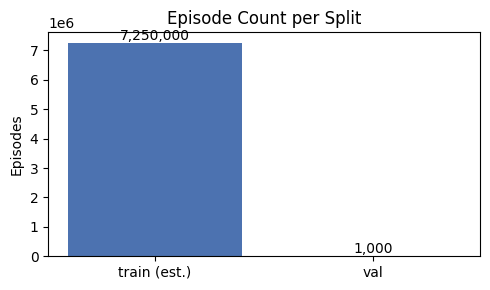

In [9]:
# Episode count per split (estimated for train)
split_counts = {"train (est.)": train_scene_count * 50_000, "val": len(all_episodes)}

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(split_counts.keys(), split_counts.values(), color=["#4C72B0", "#DD8452"])
ax.bar_label(bars, fmt="{:,.0f}")
ax.set_ylabel("Episodes")
ax.set_title("Episode Count per Split")
plt.tight_layout()
plt.show()

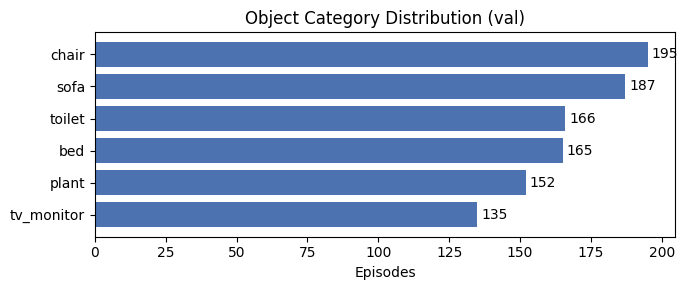

In [10]:
# Object category distribution (val split)
cat_counts = Counter(ep["object_category"] for ep in all_episodes)
cats_sorted = cat_counts.most_common()

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(
    [c[0] for c in cats_sorted],
    [c[1] for c in cats_sorted],
    color="#4C72B0",
)
ax.bar_label(bars, fmt="{:,.0f}", padding=3)
ax.set_xlabel("Episodes")
ax.set_title("Object Category Distribution (val)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

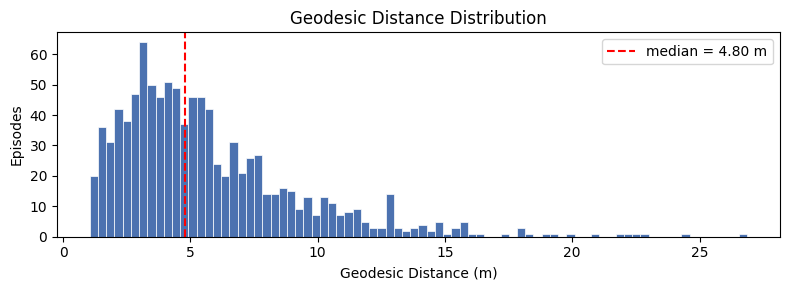

Geodesic distance: mean=5.72  median=4.80  min=1.05  max=26.87  std=3.65


In [11]:
# Geodesic distance distribution
geo_dists = []
for ep in all_episodes:
    info = ep.get("info", {})
    gd = info.get("geodesic_distance")
    if gd is not None and gd > 0:
        geo_dists.append(gd)

geo_dists = np.array(geo_dists)
median_gd = np.median(geo_dists)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(geo_dists, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.axvline(median_gd, color="red", linestyle="--", label=f"median = {median_gd:.2f} m")
ax.set_xlabel("Geodesic Distance (m)")
ax.set_ylabel("Episodes")
ax.set_title("Geodesic Distance Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Geodesic distance: mean={geo_dists.mean():.2f}  median={median_gd:.2f}  "
      f"min={geo_dists.min():.2f}  max={geo_dists.max():.2f}  std={geo_dists.std():.2f}")

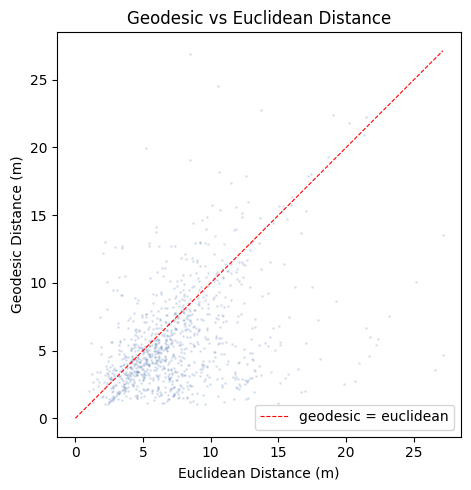

Geodesic/Euclidean ratio: mean=0.87  median=0.81
(Higher ratio → more complex navigation around obstacles/walls)


In [12]:
# Geodesic vs Euclidean distance — reveals navigation complexity
geo_vs_euc = []
for ep in all_episodes:
    info = ep.get("info", {})
    gd = info.get("geodesic_distance")
    if gd is None or gd <= 0:
        continue
    start = np.array(ep["start_position"])
    # Look up goals via goals_by_category
    goals = get_episode_goals(ep, goals_by_category)
    if not goals:
        continue
    goal_pos = np.array(goals[0]["position"])
    euc = np.linalg.norm(start - goal_pos)
    geo_vs_euc.append((euc, gd))

geo_vs_euc = np.array(geo_vs_euc)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(geo_vs_euc[:, 0], geo_vs_euc[:, 1], s=1, alpha=0.15, color="#4C72B0")
lim = max(geo_vs_euc[:, 0].max(), geo_vs_euc[:, 1].max())
ax.plot([0, lim], [0, lim], "r--", linewidth=0.8, label="geodesic = euclidean")
ax.set_xlabel("Euclidean Distance (m)")
ax.set_ylabel("Geodesic Distance (m)")
ax.set_title("Geodesic vs Euclidean Distance")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

ratios = geo_vs_euc[:, 1] / np.clip(geo_vs_euc[:, 0], 1e-3, None)
print(f"Geodesic/Euclidean ratio: mean={ratios.mean():.2f}  median={np.median(ratios):.2f}")
print("(Higher ratio → more complex navigation around obstacles/walls)")

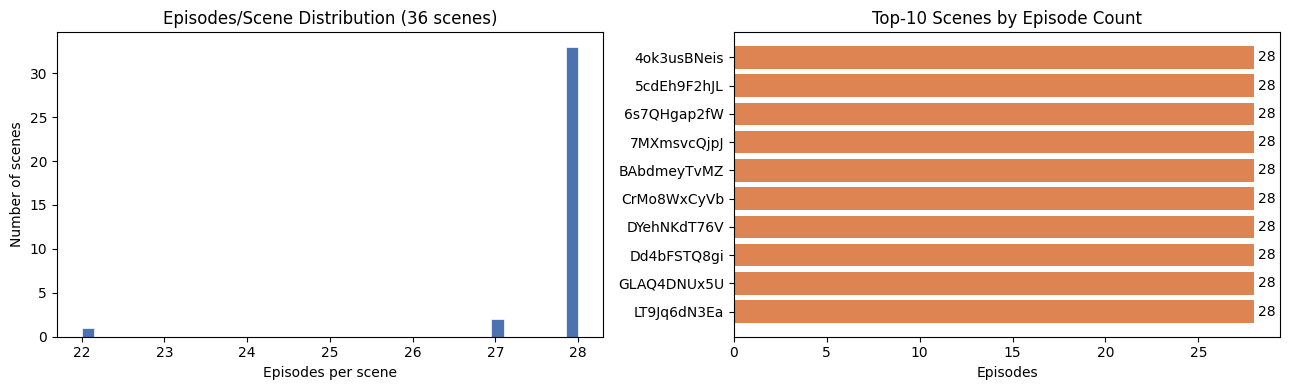

In [13]:
# Scene distribution — episodes per scene
scene_ids = [ep["scene_id"] for ep in all_episodes]
scene_counts = Counter(scene_ids)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of episodes per scene
eps_per_scene = list(scene_counts.values())
axes[0].hist(eps_per_scene, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Episodes per scene")
axes[0].set_ylabel("Number of scenes")
axes[0].set_title(f"Episodes/Scene Distribution ({len(scene_counts)} scenes)")

# Top-10 scenes
top10 = scene_counts.most_common(10)
labels = [os.path.basename(s[0]).replace(".basis.glb", "")[:20] for s in top10]
values = [s[1] for s in top10]
bars = axes[1].barh(labels, values, color="#DD8452")
axes[1].bar_label(bars, fmt="{:,.0f}", padding=3)
axes[1].set_xlabel("Episodes")
axes[1].set_title("Top-10 Scenes by Episode Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

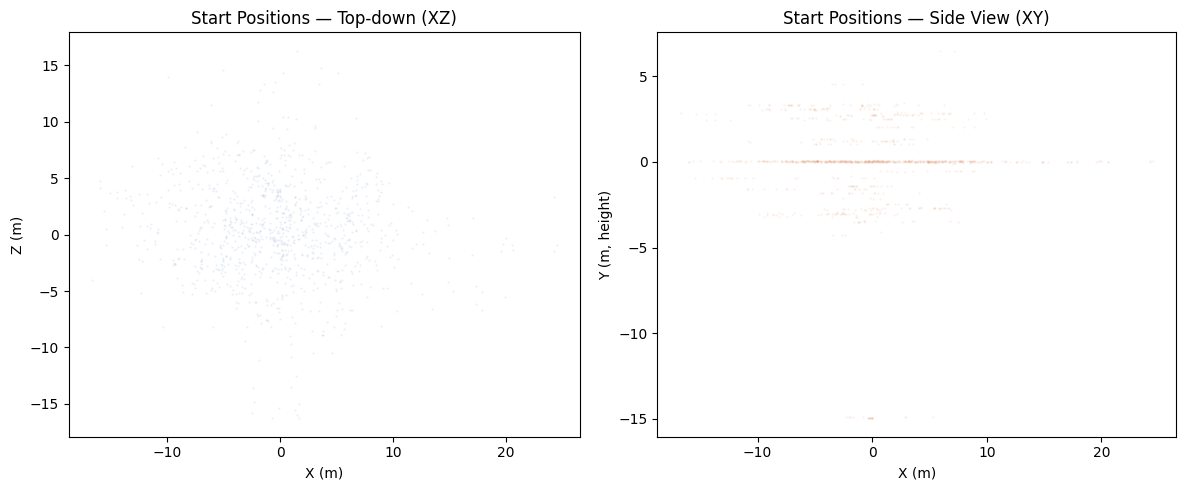

Position ranges: X=[-16.7, 24.5]  Y=[-15.0, 6.5]  Z=[-16.3, 16.3]


In [14]:
# Start positions — top-down (XZ) and side (XY) views
positions = np.array([ep["start_position"] for ep in all_episodes])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XZ (top-down)
axes[0].scatter(positions[:, 0], positions[:, 2], s=0.3, alpha=0.1, color="#4C72B0")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Z (m)")
axes[0].set_title("Start Positions — Top-down (XZ)")
axes[0].set_aspect("equal")

# XY (side)
axes[1].scatter(positions[:, 0], positions[:, 1], s=0.3, alpha=0.1, color="#DD8452")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m, height)")
axes[1].set_title("Start Positions — Side View (XY)")

plt.tight_layout()
plt.show()

print(f"Position ranges: X=[{positions[:,0].min():.1f}, {positions[:,0].max():.1f}]  "
      f"Y=[{positions[:,1].min():.1f}, {positions[:,1].max():.1f}]  "
      f"Z=[{positions[:,2].min():.1f}, {positions[:,2].max():.1f}]")

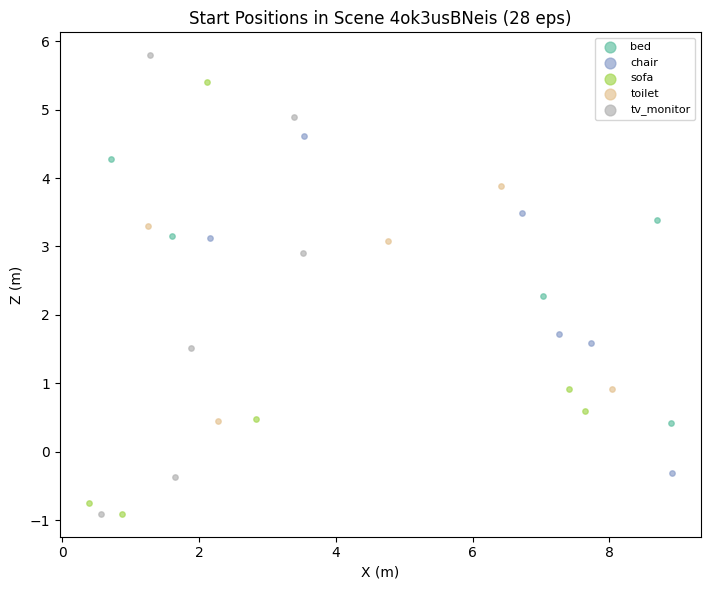

In [15]:
# Per-scene start positions colored by object category (first scene with most episodes)
top_scene_id = scene_counts.most_common(1)[0][0]
scene_eps = [ep for ep in all_episodes if ep["scene_id"] == top_scene_id]
scene_name = os.path.basename(top_scene_id).replace(".basis.glb", "")[:30]

categories = sorted(set(ep["object_category"] for ep in scene_eps))
cmap = plt.cm.Set2
cat_colors = {c: cmap(i / max(len(categories) - 1, 1)) for i, c in enumerate(categories)}

fig, ax = plt.subplots(figsize=(8, 6))
for cat in categories:
    pts = np.array([ep["start_position"] for ep in scene_eps if ep["object_category"] == cat])
    ax.scatter(pts[:, 0], pts[:, 2], s=15, alpha=0.7, color=cat_colors[cat], label=cat)
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_title(f"Start Positions in Scene {scene_name} ({len(scene_eps)} eps)")
ax.legend(fontsize=8, markerscale=2)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 5. Scene Mesh Visualization <a id='5'></a>

HM3D scene meshes (`.glb` files) require a Matterport API token to download.
This section loads and visualizes a scene mesh if available locally.

In [16]:
# Check for scene meshes
glb_files = sorted(SCENE_DIR.rglob("*.glb")) if SCENE_DIR.exists() else []

if glb_files:
    print(f"Found {len(glb_files)} .glb files under {SCENE_DIR}")
    for p in glb_files[:5]:
        print(f"  {p.relative_to(SCENE_DIR)}  ({p.stat().st_size / 1e6:.1f} MB)")
    if len(glb_files) > 5:
        print(f"  ... and {len(glb_files) - 5} more")
else:
    print("No .glb scene files found.")
    print()
    print("To download HM3D scenes:")
    print("  1. Get a Matterport API token at https://matterport.com")
    print("  2. Run:")
    print(f"     python -m habitat_sim.utils.datasets_download \\")
    print(f"       --username <API_TOKEN_ID> --password <API_TOKEN_SECRET> \\")
    print(f"       --data-path {REPO_ROOT / 'data'} \\")
    print(f"       --uids hm3d_minival")
    print()
    print("Scene visualization cells below will be skipped.")

No .glb scene files found.

To download HM3D scenes:
  1. Get a Matterport API token at https://matterport.com
  2. Run:
     python -m habitat_sim.utils.datasets_download \
       --username <API_TOKEN_ID> --password <API_TOKEN_SECRET> \
       --data-path /Users/lucamac/Coding/Master-Thesis-3D-VLA/.claude/worktrees/orktree/data \
       --uids hm3d_minival

Scene visualization cells below will be skipped.


In [17]:
if glb_files:
    import trimesh

    scene_path = glb_files[0]
    print(f"Loading scene: {scene_path.name}")
    scene_mesh = trimesh.load(scene_path, force="mesh")

    print(f"  Vertices: {len(scene_mesh.vertices):,}")
    print(f"  Faces:    {len(scene_mesh.faces):,}")
    bb = scene_mesh.bounding_box.extents
    print(f"  Bounding box: {bb[0]:.1f} x {bb[1]:.1f} x {bb[2]:.1f} m")
else:
    print("Skipped — no scene meshes available.")

Skipped — no scene meshes available.


In [18]:
if glb_files:
    import plotly.graph_objects as go

    verts = scene_mesh.vertices
    faces = scene_mesh.faces

    # Subsample if large
    max_faces = 50_000
    if len(faces) > max_faces:
        idx = np.random.default_rng(42).choice(len(faces), max_faces, replace=False)
        faces_sub = faces[idx]
        print(f"Subsampled {len(faces):,} → {max_faces:,} faces for visualization")
    else:
        faces_sub = faces

    # Get vertex colors if available
    if hasattr(scene_mesh.visual, "vertex_colors") and scene_mesh.visual.vertex_colors is not None:
        vc = scene_mesh.visual.vertex_colors[:, :3] / 255.0
        vertex_color = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in vc]
    else:
        vertex_color = None

    fig = go.Figure(data=[
        go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces_sub[:, 0], j=faces_sub[:, 1], k=faces_sub[:, 2],
            vertexcolor=vertex_color,
            opacity=0.9,
            flatshading=True,
        )
    ])
    fig.update_layout(
        title=f"Scene Mesh: {scene_path.name}",
        scene=dict(aspectmode="data"),
        width=800, height=600,
    )
    fig.show()
else:
    print("Skipped — no scene meshes available.")

Skipped — no scene meshes available.


In [19]:
if glb_files:
    import plotly.graph_objects as go

    # Find episodes for this scene
    scene_basename = scene_path.stem  # e.g. "00861-GLAQ4DNUx5U"
    matched_eps = [
        ep for ep in all_episodes
        if scene_basename in ep["scene_id"]
    ]

    if matched_eps:
        # Floor plan (XZ) with episode starts overlaid
        fig = go.Figure()

        # Scene mesh floor plan (project to XZ)
        fig.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces_sub[:, 0], j=faces_sub[:, 1], k=faces_sub[:, 2],
            vertexcolor=vertex_color,
            opacity=0.4,
            flatshading=True,
            name="Scene mesh",
        ))

        # Episode start positions
        ep_pos = np.array([ep["start_position"] for ep in matched_eps])
        ep_cats = [ep["object_category"] for ep in matched_eps]
        for cat in sorted(set(ep_cats)):
            mask = [c == cat for c in ep_cats]
            pts = ep_pos[mask]
            fig.add_trace(go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                mode="markers",
                marker=dict(size=4),
                name=f"Start: {cat}",
            ))

        fig.update_layout(
            title=f"Scene {scene_basename}: mesh + {len(matched_eps)} episode starts",
            scene=dict(aspectmode="data"),
            width=800, height=600,
        )
        fig.show()
    else:
        print(f"No episodes found for scene {scene_basename}")
else:
    print("Skipped — no scene meshes available.")

Skipped — no scene meshes available.


---
## 6. Headless Environment Test <a id='6'></a>

Try importing habitat-sim/habitat-lab and running a minimal ObjectNav episode.
Requires: habitat-sim built from source + HM3D scene files.

In [ ]:
HAS_HABITAT = False
try:
    import habitat
    import habitat_sim
    from habitat.config import read_write
    HAS_HABITAT = True
    print(f"habitat-lab: {habitat.__version__}")
    print(f"habitat-sim: {habitat_sim.__version__}")
except ImportError:
    print("habitat-sim/habitat-lab not installed.")
    print()
    print("To install (requires building from source for Python 3.12):")
    print("  git clone --recursive https://github.com/facebookresearch/habitat-sim.git")
    print("  cd habitat-sim && HEADLESS=True pip install . --no-build-isolation")
    print()
    print("  git clone --branch stable https://github.com/facebookresearch/habitat-lab.git")
    print("  pip install -e habitat-lab/habitat-lab")
    print()
    print("Cells below will be skipped.")

In [ ]:
if HAS_HABITAT and glb_files:
    # Build ObjectNav config programmatically
    config = habitat.get_config(
        config_path="benchmark/nav/objectnav/objectnav_hm3d.yaml"
    )
    with read_write(config):
        config.habitat.dataset.split = "val_mini"
        config.habitat.dataset.data_path = str(
            DATA_DIR / "{split}" / "{split}.json.gz"
        )
        # Scene dataset config — look for it next to scene files
        scene_cfg_candidates = [
            SCENE_DIR / "hm3d_annotated_basis.scene_dataset_config.json",
            *SCENE_DIR.rglob("*scene_dataset_config.json"),
        ]
        scene_cfg = next((p for p in scene_cfg_candidates if p.exists()), None)
        if scene_cfg:
            config.habitat.simulator.scene_dataset = str(scene_cfg)
        # Reduce resolution for speed
        agent_cfg = config.habitat.simulator.agents.main_agent
        for sensor in ["rgb_sensor", "depth_sensor"]:
            s = getattr(agent_cfg.sim_sensors, sensor)
            s.width = 256
            s.height = 256

    env = habitat.Env(config=config)
    obs = env.reset()
    print("Environment created and reset successfully!")
    print(f"Episode: {env.current_episode.episode_id}")
    print(f"Scene:   {env.current_episode.scene_id}")
    print(f"Target:  {env.current_episode.object_category}")
    print(f"\nObservation keys: {list(obs.keys())}")
    for k, v in obs.items():
        if hasattr(v, "shape"):
            print(f"  {k}: shape={v.shape} dtype={v.dtype}")
        else:
            print(f"  {k}: {v}")
else:
    reasons = []
    if not HAS_HABITAT:
        reasons.append("habitat not installed")
    if not glb_files:
        reasons.append("no scene meshes")
    print(f"Skipped — {', '.join(reasons)}.")

In [ ]:
if HAS_HABITAT and glb_files:
    # Take a few random actions and collect observations
    actions = [1, 2, 1, 1, 3, 1]  # fwd, left, fwd, fwd, right, fwd
    action_names = {0: "STOP", 1: "FORWARD", 2: "LEFT", 3: "RIGHT"}

    frames = [obs]
    for a in actions:
        obs = env.step(action=a)
        frames.append(obs)

    # Visualize RGB + depth for first 4 steps
    n_show = min(4, len(frames))
    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
    for i in range(n_show):
        axes[0, i].imshow(frames[i]["rgb"])
        axes[0, i].set_title(f"Step {i}: {action_names.get(actions[i-1], 'reset') if i > 0 else 'reset'}")
        axes[0, i].axis("off")

        axes[1, i].imshow(frames[i]["depth"].squeeze(), cmap="plasma")
        axes[1, i].set_title(f"Depth {i}")
        axes[1, i].axis("off")

    plt.suptitle(f"ObjectNav: target={env.current_episode.object_category}", y=1.02)
    plt.tight_layout()
    plt.show()

    env.close()
    print("Environment closed.")
else:
    print("Skipped.")

### Environment test checklist
- [ ] habitat-sim imports successfully
- [ ] Scene loads without OpenGL errors (headless)
- [ ] Observations have expected shapes (RGB: 256×256×3, Depth: 256×256×1)
- [ ] Actions execute without errors
- [ ] Episode info contains geodesic_distance, success, spl

---
## 7. Evaluation Metrics <a id='7'></a>

### Success Rate (SR)

$$\text{SR} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\left[ d_\text{geo}(\text{agent}_i, \text{goal}_i) < 1.0 \right]$$

### Success weighted by Path Length (SPL)

$$\text{SPL} = \frac{1}{N} \sum_{i=1}^{N} S_i \cdot \frac{l_i}{\max(p_i, l_i)}$$

where $S_i$ = success indicator, $l_i$ = shortest path length, $p_i$ = actual path length.

SPL penalizes inefficient paths — a successful but meandering agent scores lower.

### SoftSPL

$$\text{SoftSPL} = \frac{1}{N} \sum_{i=1}^{N} \max\!\left(0, 1 - \frac{d_\text{final}}{d_\text{start}}\right) \cdot \frac{l_i}{\max(p_i, l_i)}$$

Gives partial credit for progress toward the goal even without success.

### Distance to Goal (DTG)

$$\text{DTG} = \frac{1}{N} \sum_{i=1}^{N} d_\text{geo}(\text{agent}_i^\text{final}, \text{goal}_i)$$

In [20]:
# Worked SPL examples
examples = [
    {"Agent": "Perfect",      "Success": 1, "Shortest (l)": 5.0, "Actual (p)": 5.0},
    {"Agent": "Inefficient",  "Success": 1, "Shortest (l)": 5.0, "Actual (p)": 15.0},
    {"Agent": "Failed",       "Success": 0, "Shortest (l)": 5.0, "Actual (p)": 20.0},
    {"Agent": "Lucky short",  "Success": 1, "Shortest (l)": 5.0, "Actual (p)": 3.0},
]

print(f"{'Agent':<16} {'Success':>8} {'l':>6} {'p':>6} {'SPL':>8}")
print("-" * 48)
for ex in examples:
    s, l, p = ex["Success"], ex["Shortest (l)"], ex["Actual (p)"]
    spl = s * l / max(p, l)
    print(f"{ex['Agent']:<16} {s:>8} {l:>6.1f} {p:>6.1f} {spl:>8.3f}")

Agent             Success      l      p      SPL
------------------------------------------------
Perfect                 1    5.0    5.0    1.000
Inefficient             1    5.0   15.0    0.333
Failed                  0    5.0   20.0    0.000
Lucky short             1    5.0    3.0    1.000


---
## 8. Connection to Thesis <a id='8'></a>

### Baseline vs Proposed

| | Baseline | Proposed |
|---|---|---|
| **Model** | OpenVLA (2D vision-language-action) | OpenVLA + UNITE 3D features |
| **Observations** | RGB-D (2D) | RGB-D + dense 3D semantic features |
| **3D Understanding** | None (implicit from depth) | Explicit: CLIP + instance + articulation |
| **Evaluation** | HM3D ObjectNav (SR, SPL) | HM3D ObjectNav (SR, SPL) |

### Difficulty Stratification

The `geodesic_distance` field enables stratifying results by difficulty:
- **Easy**: geodesic < 5 m (object in same room)
- **Medium**: 5–10 m (adjacent rooms)
- **Hard**: > 10 m (multi-room navigation)

Hypothesis: UNITE 3D features help most on **hard** episodes where spatial reasoning across rooms is critical.

### Summary

| Property | Value |
|----------|-------|
| Benchmark | HM3D ObjectNav v2 |
| Scenes | 216 (train: 145, val: 36, test: 35) |
| Object categories | 6 (chair, couch, potted plant, bed, toilet, TV) |
| Success criterion | STOP within 1.0 m geodesic of goal |
| Max steps | 500 |
| Primary metrics | SR, SPL |
| Obs space | RGB-D 256×256 + GPS + Compass |
| Action space | STOP, FORWARD(0.25m), LEFT/RIGHT(30°) |